In [19]:
import fastf1
import pandas as pd 
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

if not os.path.exists('../cache'):
    os.makedirs('../cache')

fastf1.Cache.enable_cache('../cache')

print("Laboratorio configurado e cache do FastF1 ativado com sucesso!")

Laboratorio configurado e cache do FastF1 ativado com sucesso!


In [5]:
session = fastf1.get_session(2024, 'São Paulo Grand Prix', 'R') #Puxa os dados da sessao de corrida escolhida dentro do parenteses
session.load()  # Carrega os dados da sessão

core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished lo

In [6]:
voltas = session.laps 
voltas.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [7]:
voltas_vers = voltas.pick_drivers('VER') #Filtra apenas as voltas do piloto escolhido dentro do parenteses
voltas_vers_limpas = voltas_vers.pick_accurate() #Filtra apenas as voltas limpas do piloto escolhido dentro do parenteses
dados_modeloML = voltas_vers_limpas[['LapNumber', 'Stint', 'Compound', 'TyreLife', 'LapTime']].copy()
dados_modeloML['LapTime'] = dados_modeloML['LapTime'].dt.total_seconds() 
dados_modeloML = pd.get_dummies(dados_modeloML, columns=['Compound'], dtype=int) #transforma em binario para o modelo de ML conseguir ler
dados_modeloML.head(5)

,LapNumber,Stint,TyreLife,LapTime,Compound_INTERMEDIATE
1,2.0,1.0,2.0,87.134,1
2,3.0,1.0,3.0,86.240,1
3,4.0,1.0,4.0,86.702,1
4,5.0,1.0,5.0,85.394,1
5,6.0,1.0,6.0,84.311,1


In [21]:
dados_modeloML = dados_modeloML[dados_modeloML['LapTime'] < 90] #Filtra apenas as voltas com tempo menor que 90 segundos, para evitar outliers

In [22]:
y = dados_modeloML['LapTime']
X = dados_modeloML.drop(columns=['LapTime'])

print("Tamanho do X (Features):", X.shape)
print("Tamanho do y (Target):", y.shape)

X.head()

Tamanho do X (Features): (56, 4)
Tamanho do y (Target): (56,)


,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE
1,2.0,1.0,2.0,1
2,3.0,1.0,3.0,1
3,4.0,1.0,4.0,1
4,5.0,1.0,5.0,1
5,6.0,1.0,6.0,1


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamanho do X_train:", X_train.shape)
print("Tamanho do X_test:", X_test.shape)
print("Tamanho do y_train:", y_train.shape)
print("Tamanho do y_test:", y_test.shape)

Tamanho do X_train: (44, 4)
Tamanho do X_test: (12, 4)
Tamanho do y_train: (44,)
Tamanho do y_test: (12,)


In [24]:
modelo = AdaBoostRegressor(random_state=42)
modelo.fit(X_train, y_train)


#Aqui vemos q o adaboost criou uma sequencia de 50 arvores encadeadas, tentando corrigir os erros da anterior
#os atributos treinados foram o tyrelife q teve um percentual de importancia de 64%, lapnumber de 36%, stint 1% compound de 0%

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
Name,Type,Value
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeRegressor,DecisionTreeR...r(max_depth=3)
estimator_errors_ estimator_errors_: ndarray of floatsRegression error for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.18,0.14,0.29,...,0.31,0.14,0.32]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.54,1.82,0.89,...,0.8 ,1.83,0.74]"
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators.,list,"[DecisionTreeR...te=1608637542), DecisionTreeR...ate=782698033), DecisionTreeR...te=2028147648), DecisionTreeR...te=1048511127), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](4,)","[0.6 ,0.02,0.38,0. ]"


In [25]:
previsoes = modelo.predict(X_test)

print("Previsões:", previsoes[:5])  # Exibe as primeiras 5 previsões

Previsões: [86.394      84.3965     82.876      84.65444444 84.65444444]


In [26]:
print("Erro médio absoluto (MAE):", mean_absolute_error(y_test, previsoes))

Erro médio absoluto (MAE): 0.4776132936507942


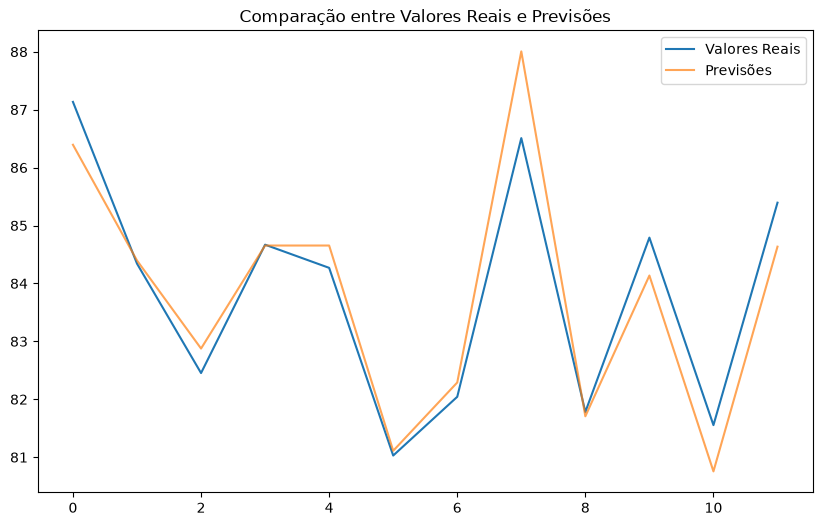

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.reset_index(drop=True), label='Valores Reais')
plt.plot(previsoes, label='Previsões', alpha=0.7)
plt.legend()
plt.title('Comparação entre Valores Reais e Previsões')
plt.show()

In [29]:
X.columns
dados_simulados = {
    'LapNumber' : list(range(1, 31)),
    'Stint' : [1.0] * 30,
    'TyreLife' : list(range(1, 31)),
    'Compound_INTERMEDIATE' : [1] * 30
}

df_simulacaoPista = pd.DataFrame(dados_simulados)
df_simulacaoPista = df_simulacaoPista[X.columns]  # Reordena as colunas para corresponder ao conjunto de treinamento
tempos_simulados = modelo.predict(df_simulacaoPista)
df_simulacaoPista.head()

,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE
0,1,1.0,1,1
1,2,1.0,2,1
2,3,1.0,3,1
3,4,1.0,4,1
4,5,1.0,5,1


,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE,Tempo_Previsto
0,1,1.0,1,1,86.394000
1,2,1.0,2,1,86.394000
2,3,1.0,3,1,86.394000
3,4,1.0,4,1,86.471000
4,5,1.0,5,1,84.634857


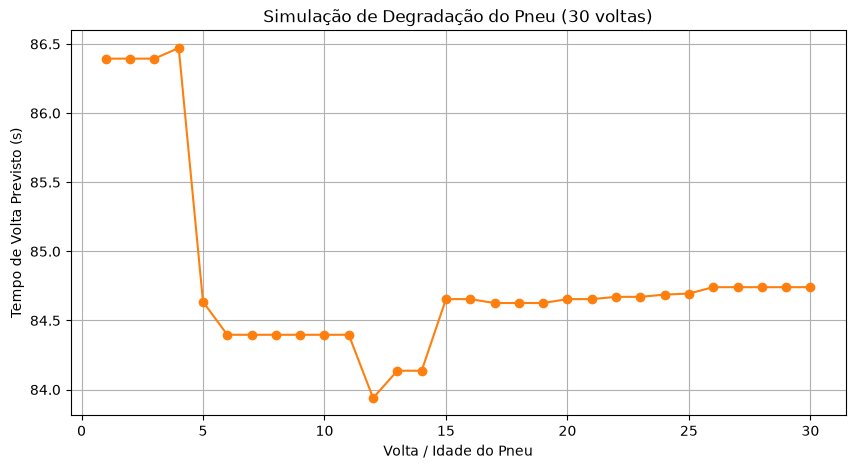

In [32]:
df_simulacaoPista['Tempo_Previsto'] = tempos_simulados

display(df_simulacaoPista.head())

plt.figure(figsize=(10, 5))
plt.plot(df_simulacaoPista['LapNumber'], df_simulacaoPista['Tempo_Previsto'], marker='o', color='#ff7f0e')
plt.title('Simulação de Degradação do Pneu (30 voltas)')
plt.xlabel('Volta / Idade do Pneu')
plt.ylabel('Tempo de Volta Previsto (s)')
plt.grid(True)
plt.show()